<a href="https://colab.research.google.com/github/kirthankulkarni-bit/assip-ML-stress-monitoring/blob/main/train_rf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# load csv file of new feature dataset from feature extraction script
from google.colab import drive

# unmount drive if already mounted
if 'drive' in locals() and os.path.exists('/content/drive'):
    try:
        drive.flush_and_unmount()
        print("drive unmounted")
    except Exception as e:
        print(f"error: {e}")

drive.mount('/content/drive')

csv_path = '/content/drive/MyDrive/ASSIP/wesad_subject2_features.csv'
print(f"reading feature matrix from: {csv_path}")
df = pd.read_csv(csv_path)

print(f"Dataset shape: {df.shape}")
print(df.head())


Mounted at /content/drive
reading feature matrix from: /content/drive/MyDrive/ASSIP/wesad_subject2_features.csv
Dataset shape: (59, 7)
   eda_mean   eda_std   eda_max   eda_min  bvp_hr_bpm     bvp_std  label
0 -0.001474  0.086600  0.229437 -0.321039          76  118.365504      1
1 -0.001922  0.063971  0.229437 -0.171227          75   94.285021      1
2  0.000088  0.013425  0.049678 -0.041769          77   42.776082      1
3  0.000145  0.006877  0.024533 -0.026218          76   38.841310      1
4  0.000825  0.010878  0.055331 -0.020602          73   70.243291      1


In [9]:
# split x and y; x is features, y is target (stress - 2 or baseline - 1)
x = df.drop(columns=['label'])
y = df['label']

# random forest classifier ML model is used for this project because it works well with biological data, prevents overfitiing on small datasets and has a property that explains its feature ranking (feature importance)
# split process of training/testing on rf model chronologically to avoid time-series data leakage

# updated training/testing to stratified split method (80% training and 20% testing)
# guarantees both training and testing have same percent of stress/baseline
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, stratify=y, random_state=42)

print(f"training samples: {len(x_train)} ({len(y_train[y_train==1])} baseline, {len(y_train[y_train==2])} stress)")
print(f"testing samples:  {len(x_test)} ({len(y_test[y_test==1])} baseline, {len(y_test[y_test==2])} stress)")


training samples: 47 (30 baseline, 17 stress)
testing samples:  12 (8 baseline, 4 stress)


              precision    recall  f1-score   support

    Baseline       1.00      1.00      1.00         8
      Stress       1.00      1.00      1.00         4

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



/tmp/ipykernel_876/644879359.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features_ranked, palette='viridis')


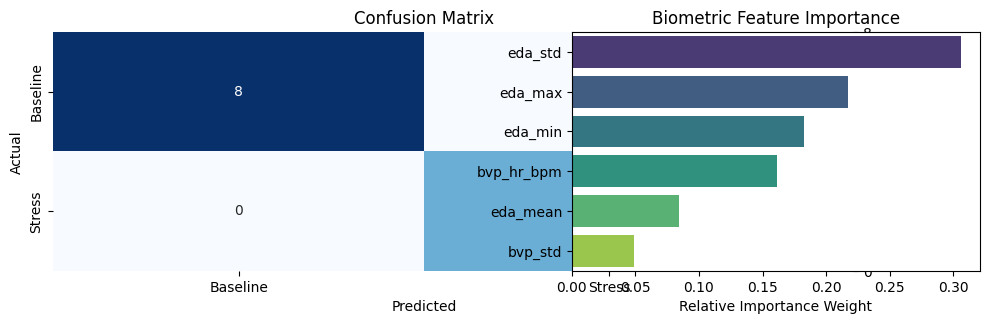


=== Feature Importance Ranking ===
1. eda_std      : 0.3058 (30.6%)
2. eda_max      : 0.2173 (21.7%)
3. eda_min      : 0.1830 (18.3%)
4. bvp_hr_bpm   : 0.1610 (16.1%)
5. eda_mean     : 0.0841 (8.4%)
6. bvp_std      : 0.0487 (4.9%)


In [12]:
# random forest classification; since dataset is unbalanced, setting class weight to balanced helps remove biases
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(x_train, y_train)
y_pred = rf_model.predict(x_test)

# model evaluation stage
print(classification_report(y_test, y_pred, target_names=['Baseline', 'Stress']))

# plot 1: creates confusion matrix and heat map directly over confusion matrix using seaborn library
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Baseline', 'Stress'], yticklabels=['Baseline', 'Stress'])

plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# plot 2: random forest feature importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features_ranked = [x.columns[i] for i in indices]

plt.subplot(1, 2, 2)
sns.barplot(x=importances[indices], y=features_ranked, palette='viridis')
plt.title('Biometric Feature Importance')
plt.xlabel('Relative Importance Weight')

plt.tight_layout()
plt.show()

# shows the numerical importance of each feature ranked in order
print("\n=== Feature Importance Ranking ===" )
for rank, (feat, imp) in enumerate(zip(features_ranked, importances[indices]), 1):
    print(f"{rank}. {feat:<12} : {imp:.4f} ({imp*100:.1f}%)")